<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/3_03_SingleCell_and_Spatial_Transcriptomics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 — Single-Cell Genomics & Spatial Transcriptomics

**Advanced Bioinformatics Lab Session**

## Learning objectives
- Simulate a droplet-based single-cell RNA-seq count matrix (10x Genomics–style) with realistic dropout and library-size variation
- Run the standard single-cell workflow: QC filtering → normalization → dimensionality reduction (PCA) → clustering → 2D embedding
- Interpret clusters in the context of tumor heterogeneity / immune profiling
- Simulate and visualize spatial transcriptomics data (gene expression mapped to tissue coordinates) and explore the tumor microenvironment

We work with `numpy`/`pandas`/`scikit-learn` directly rather than `scanpy`, so every step of the pipeline is transparent.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

np.random.seed(11)
sns.set_theme(style="whitegrid", font_scale=1.05)


## 1. Simulate a droplet-based single-cell count matrix

We model a tumor biopsy with 4 underlying cell populations (e.g. malignant epithelial cells, T cells, macrophages, fibroblasts), each with a distinct marker gene expression program, plus dropout (a hallmark of droplet-based scRNA-seq: many true transcripts are not captured).

In [ ]:
N_CELLS = 1200
N_GENES = 300
CELL_TYPES = ["Malignant_epithelial", "T_cell", "Macrophage", "Fibroblast"]
TYPE_PROPORTIONS = [0.45, 0.25, 0.18, 0.12]  # tumor content vs. immune infiltrate vs. stroma

# marker genes: first 20 genes per cell type are that type's "signature"
marker_blocks = {ct: list(range(i*20, i*20+20)) for i, ct in enumerate(CELL_TYPES)}

def simulate_cell(cell_type, n_genes=N_GENES, base_lambda=1.2, marker_lambda=15, library_scale=None):
    lam = np.full(n_genes, base_lambda)
    lam[marker_blocks[cell_type]] = marker_lambda
    if library_scale is not None:
        lam = lam * library_scale
    counts = np.random.poisson(lam)
    # dropout: probability of observing 0 increases for low-expression genes (ambient/capture noise)
    dropout_prob = np.clip(0.5 - 0.03*np.log1p(lam), 0.02, 0.6)
    dropout_mask = np.random.rand(n_genes) < dropout_prob
    counts[dropout_mask] = 0
    return counts

labels = np.random.choice(CELL_TYPES, size=N_CELLS, p=TYPE_PROPORTIONS)
library_scales = np.random.lognormal(mean=0, sigma=0.35, size=N_CELLS)  # cell-to-cell library size variation

count_matrix = np.array([simulate_cell(ct, library_scale=ls) for ct, ls in zip(labels, library_scales)])
gene_names = [f"Gene_{i}" for i in range(N_GENES)]
adata = pd.DataFrame(count_matrix, columns=gene_names)
adata["true_cell_type"] = labels
adata.head()


,Gene_0,Gene_1,Gene_2,Gene_3,Gene_4,Gene_5,Gene_6,Gene_7,Gene_8,Gene_9,...,Gene_291,Gene_292,Gene_293,Gene_294,Gene_295,Gene_296,Gene_297,Gene_298,Gene_299,true_cell_type
0,0,11,9,0,11,12,13,0,0,0,...,0,0,2,0,1,1,1,0,0,Malignant_epithelial
1,0,16,11,10,0,0,0,10,9,15,...,2,0,0,2,0,1,0,0,0,Malignant_epithelial
2,0,2,0,0,0,0,2,0,1,2,...,0,0,0,1,3,1,1,1,0,T_cell
3,0,2,0,0,0,0,0,1,0,0,...,0,0,1,2,2,0,0,0,0,Macrophage
4,0,25,0,19,0,15,0,14,0,12,...,0,0,1,0,0,1,0,0,0,Malignant_epithelial


## 2. QC filtering — remove low-quality droplets (empty/dying cells, doublets)

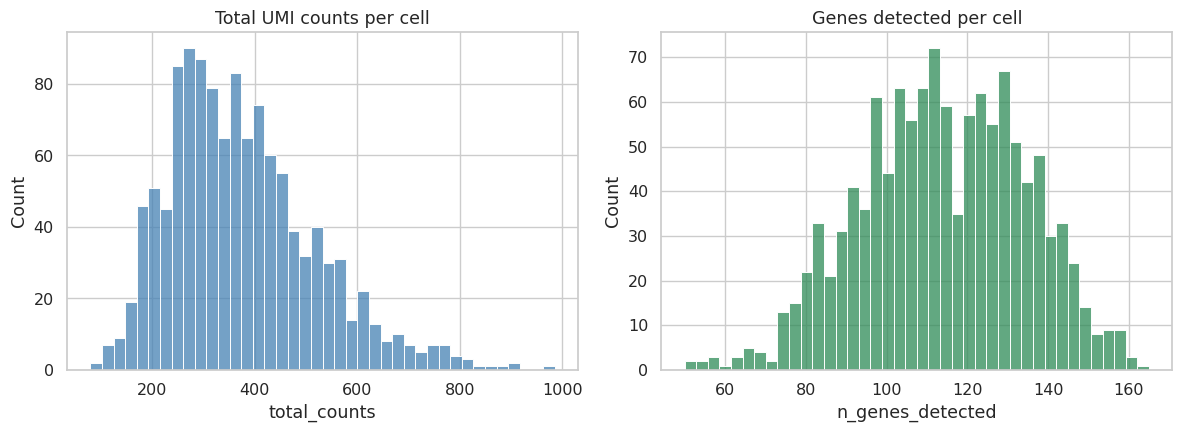

Cells passing QC: 1200 / 1200  (100.0%)


In [ ]:
adata["total_counts"] = adata[gene_names].sum(axis=1)
adata["n_genes_detected"] = (adata[gene_names] > 0).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
sns.histplot(adata["total_counts"], bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Total UMI counts per cell")
sns.histplot(adata["n_genes_detected"], bins=40, ax=axes[1], color="seagreen")
axes[1].set_title("Genes detected per cell")
plt.tight_layout(); plt.show()

MIN_COUNTS, MIN_GENES = 50, 20
qc_pass = (adata["total_counts"] >= MIN_COUNTS) & (adata["n_genes_detected"] >= MIN_GENES)
print(f"Cells passing QC: {qc_pass.sum()} / {len(adata)}  ({qc_pass.mean():.1%})")
adata_filt = adata.loc[qc_pass].reset_index(drop=True)


## 3. Normalization (library-size normalization + log transform)

In [ ]:
counts_filt = adata_filt[gene_names].values.astype(float)
size_factors = counts_filt.sum(axis=1, keepdims=True) / np.median(counts_filt.sum(axis=1))
norm_counts = counts_filt / size_factors
log_norm = np.log1p(norm_counts)

print("Before normalization — mean total counts CV:", (counts_filt.sum(axis=1).std() / counts_filt.sum(axis=1).mean()).round(3))
print("After  normalization — mean total counts CV:", (norm_counts.sum(axis=1).std() / norm_counts.sum(axis=1).mean()).round(3))


Before normalization — mean total counts CV: 0.38
After  normalization — mean total counts CV: 0.0


## 4. Dimensionality reduction: PCA → clustering → 2D embedding

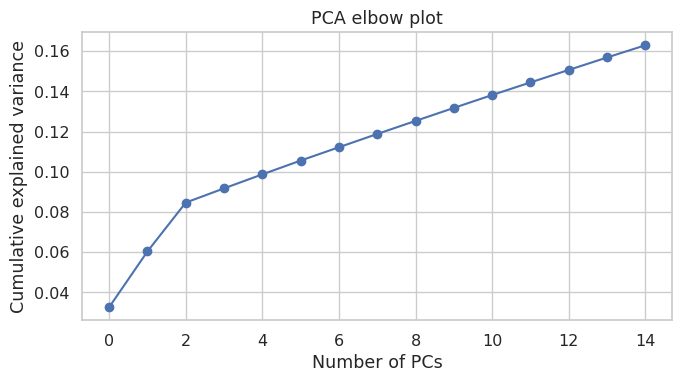

In [ ]:
scaled = StandardScaler().fit_transform(log_norm)
pca = PCA(n_components=15, random_state=0)
pcs = pca.fit_transform(scaled)

plt.figure(figsize=(7,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
plt.xlabel("Number of PCs"); plt.ylabel("Cumulative explained variance")
plt.title("PCA elbow plot"); plt.tight_layout(); plt.show()


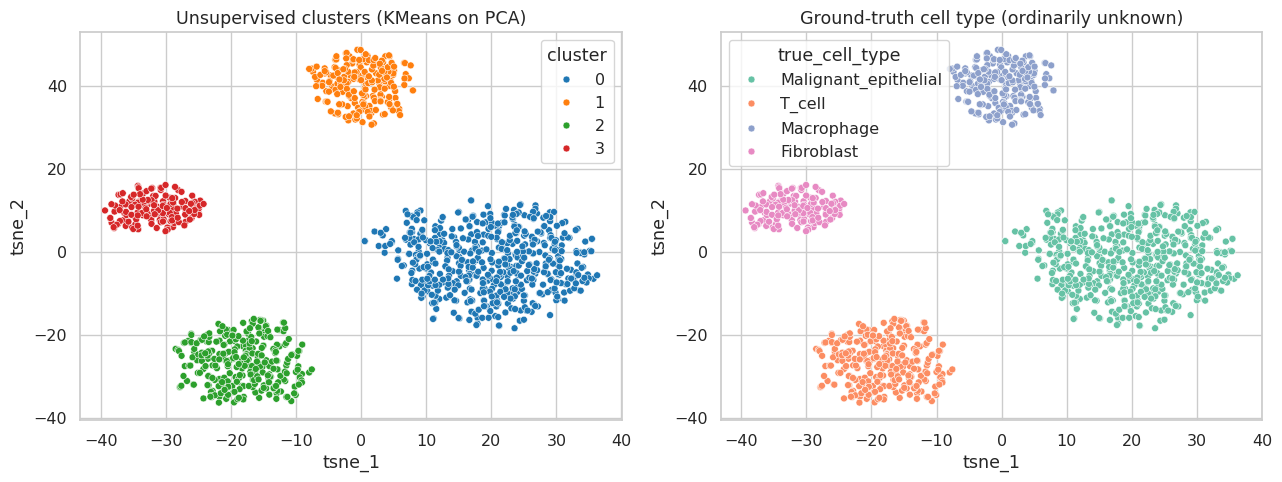

In [ ]:
N_CLUSTERS = 4  # we know there are 4 simulated populations; in practice this is estimated
kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=0)
cluster_labels = kmeans.fit_predict(pcs[:, :10])
adata_filt["cluster"] = cluster_labels

tsne = TSNE(n_components=2, perplexity=30, random_state=0, init="pca")
embedding = tsne.fit_transform(pcs[:, :10])
adata_filt["tsne_1"], adata_filt["tsne_2"] = embedding[:,0], embedding[:,1]

fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=adata_filt, x="tsne_1", y="tsne_2", hue="cluster", palette="tab10", ax=axes[0], s=25)
axes[0].set_title("Unsupervised clusters (KMeans on PCA)")
sns.scatterplot(data=adata_filt, x="tsne_1", y="tsne_2", hue="true_cell_type", palette="Set2", ax=axes[1], s=25)
axes[1].set_title("Ground-truth cell type (ordinarily unknown)")
plt.tight_layout(); plt.show()


## 5. Exercise — Cluster annotation by marker gene expression

In a real analysis you don't have `true_cell_type` — you annotate clusters by inspecting marker gene expression. Score each cluster's mean expression of each cell type's marker block and assign identities.

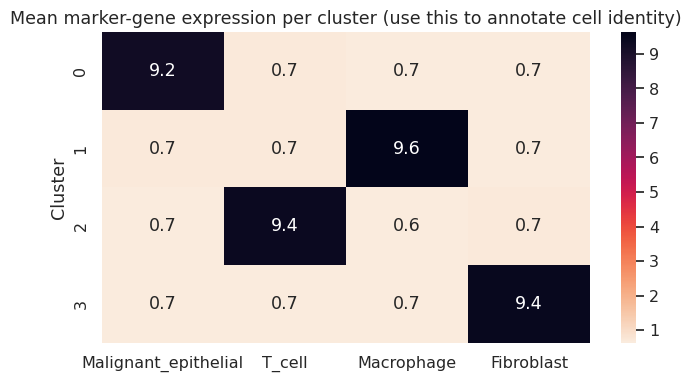

Inferred cluster identities:
 0    Malignant_epithelial
1              Macrophage
2                  T_cell
3              Fibroblast
dtype: str


In [ ]:
marker_scores = pd.DataFrame(index=sorted(adata_filt["cluster"].unique()))
for ct, genes_idx in marker_blocks.items():
    genes = [gene_names[i] for i in genes_idx]
    marker_scores[ct] = adata_filt.groupby("cluster")[genes].mean().mean(axis=1)

plt.figure(figsize=(7,4))
sns.heatmap(marker_scores, annot=True, fmt=".1f", cmap="rocket_r")
plt.title("Mean marker-gene expression per cluster (use this to annotate cell identity)")
plt.ylabel("Cluster"); plt.tight_layout(); plt.show()

inferred_identity = marker_scores.idxmax(axis=1)
print("Inferred cluster identities:\n", inferred_identity)


## 6. Spatial transcriptomics — mapping expression to tissue coordinates

Now we simulate a spatial assay (e.g. Visium-style slide-based barcoding): each spot has (x, y) coordinates on a tissue section **and** a gene expression profile, letting us study the tumor microenvironment — e.g. whether immune cells cluster at the tumor margin or infiltrate the core.

In [ ]:
GRID = 40  # 40x40 spot array
xs, ys = np.meshgrid(np.arange(GRID), np.arange(GRID))
xs, ys = xs.flatten(), ys.flatten()
center = GRID / 2

# distance from tumor core defines a gradient of cell-type composition
dist_from_core = np.sqrt((xs-center)**2 + (ys-center)**2)
dist_norm = dist_from_core / dist_from_core.max()

spatial_rows = []
for x, y, d in zip(xs, ys, dist_norm):
    # tumor core -> malignant epithelial; margin -> immune infiltrate; far edge -> stroma
    if d < 0.35:
        probs = [0.75, 0.15, 0.05, 0.05]
    elif d < 0.65:
        probs = [0.25, 0.45, 0.25, 0.05]
    else:
        probs = [0.05, 0.15, 0.15, 0.65]
    ct = np.random.choice(CELL_TYPES, p=probs)
    counts = simulate_cell(ct, library_scale=1.0)
    row = {"x": x, "y": y, "dist_from_core": d, "dominant_cell_type": ct}
    row.update({g: c for g, c in zip(gene_names, counts)})
    spatial_rows.append(row)

spatial_df = pd.DataFrame(spatial_rows)
spatial_df[["x","y","dist_from_core","dominant_cell_type"]].head()


,x,y,dist_from_core,dominant_cell_type
0,0,0,1.000000,Fibroblast
1,1,0,0.975320,Fibroblast
2,2,0,0.951315,Malignant_epithelial
3,3,0,0.928036,Malignant_epithelial
4,4,0,0.905539,Fibroblast


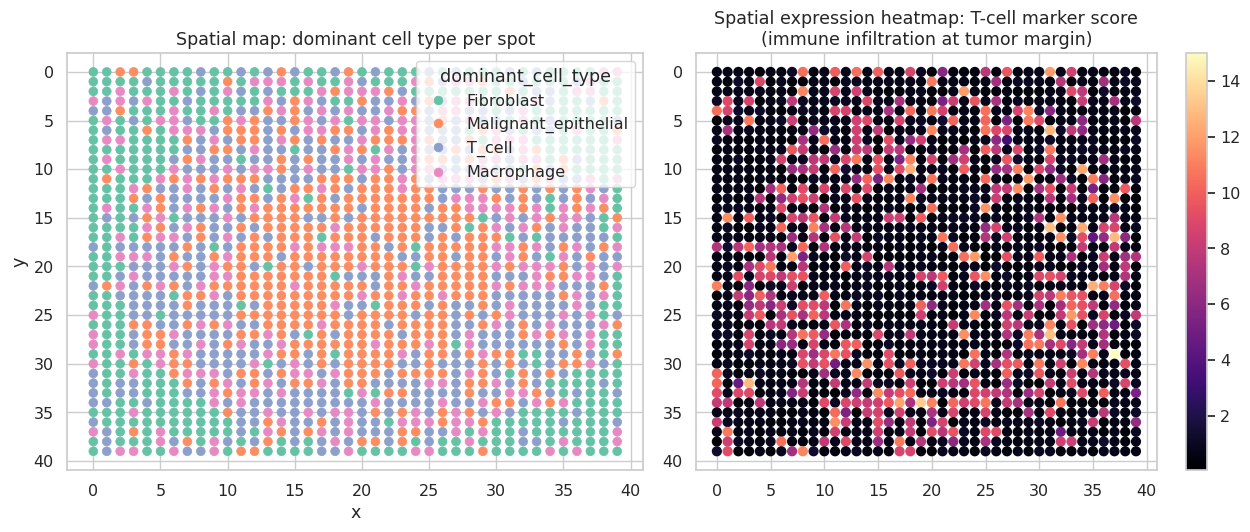

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13,5.5))

sns.scatterplot(data=spatial_df, x="x", y="y", hue="dominant_cell_type",
                 palette="Set2", ax=axes[0], s=40, edgecolor=None)
axes[0].set_title("Spatial map: dominant cell type per spot")
axes[0].invert_yaxis()

t_cell_marker_genes = [gene_names[i] for i in marker_blocks["T_cell"]]
spatial_df["T_cell_score"] = spatial_df[t_cell_marker_genes].mean(axis=1)
sc = axes[1].scatter(spatial_df["x"], spatial_df["y"], c=spatial_df["T_cell_score"], cmap="magma", s=40)
axes[1].set_title("Spatial expression heatmap: T-cell marker score\n(immune infiltration at tumor margin)")
axes[1].invert_yaxis()
plt.colorbar(sc, ax=axes[1])
plt.tight_layout(); plt.show()


## 7. Exercise — Tumor microenvironment analysis

1. Using `spatial_df`, compute the mean **T-cell score** separately for the tumor core (`dist_from_core < 0.35`), margin (`0.35–0.65`), and stroma (`> 0.65`). Does the result match the "immune infiltrate at the margin" pattern typically seen in solid tumors?
2. Repeat the analysis for the **Macrophage** marker score — do macrophages follow the same spatial pattern as T cells, or a different one?
3. In your own words: why is spatial transcriptomics able to answer questions that dissociated single-cell RNA-seq (Section 1–5) cannot?


In [ ]:
zones = pd.cut(spatial_df["dist_from_core"], bins=[0, 0.35, 0.65, 1.0], labels=["Core", "Margin", "Stroma"])
spatial_df["zone"] = zones

macrophage_genes = [gene_names[i] for i in marker_blocks["Macrophage"]]
spatial_df["Macrophage_score"] = spatial_df[macrophage_genes].mean(axis=1)

zone_summary = spatial_df.groupby("zone")[["T_cell_score", "Macrophage_score"]].mean().round(2)
zone_summary


,T_cell_score,Macrophage_score
zone,,
Core,2.00,1.23
Margin,4.11,2.70
Stroma,1.89,1.78
